In [1]:
import sys
import os
import pandas as pd
import numpy as np
import torch
import copy
import pandas as pd
import torch
import yaml
from enviroment import Stock_Env
from agent import PPO
from grpo import test_grpo

Current working directory: /workspace/portfolio_price_discrete_rebal_step_1m


In [16]:


def set_seed(seed):
    # random.seed(seed)
    # np.random.seed(seed)
    torch.manual_seed(seed)
    # torch.cuda.manual_seed(seed)
    # torch.cuda.manual_seed_all(seed)  # Multi-GPU 환경 고려
    # torch.backends.cudnn.deterministic = True
    # torch.backends.cudnn.benchmark = False
    print(f"Random seed set to: {seed}")

SEED = 42
set_seed(SEED)

with open("./config/test_config.yaml", "r") as f:
    config = yaml.safe_load(f)
    

index_train_path = "../data/train_v3.csv"
index_test_path = "../data/test_v3.csv"
future_train_path = "../data/future_train_v3.csv"
future_test_path = "../data/future_test_v3.csv"
test_pt = "../data/portfolio_price/portfolio_test_v4.pt"



device = torch.device(config.get("device", "cuda:0"))
config["device"] = device

index_train_for_valid = pd.read_csv(index_train_path, index_col=0)
index_test_df = pd.read_csv(index_test_path, index_col=0)

index_test_all_df = pd.concat([index_train_for_valid, index_test_df], axis=0)
index_test_all_df.reset_index(drop=True, inplace=True)
index_test_all_df.set_index("date", inplace=True)

future_train_for_valid = pd.read_csv(future_train_path, index_col=0)
future_test_df = pd.read_csv(future_test_path, index_col=0)
future_test_all_df = pd.concat([future_train_for_valid, future_test_df], axis=0)
future_test_all_df.reset_index(drop=True, inplace=True)
future_test_all_df.set_index("date", inplace=True)


test_tensor = torch.load(test_pt, map_location=device)
traj_len ="1m"
update_interval = config["update_interval_map"].get(traj_len, 60)
config["update_interval"] = update_interval
config["batch_samples"] = config["batch_samples"].get(traj_len, 5)
config["TRADE_START_DATE"] = "2019-01-01"
config["TRADE_END_DATE"] = "2024-12-31"
env = Stock_Env(config=config, states=test_tensor, index_df=index_test_all_df, future_df = future_test_all_df, eval=True)


agent = PPO(env, eval=True)
model_path =  "./model/present/final_1m_actor_lr1e-05_clip_grad1_epslion_0.1batch_sample_1024_mu50_num_group16_num_steps10_reward_cond_sharpe_grpo_model.pth"
agent.load(model_path)
model_return, strategy_returns, weight_rebal, strategy_weights = test_grpo(env, agent)

Random seed set to: 42


/tmp/ipykernel_14769/3839366834.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  test_tensor = torch.load(test_pt, map_location=device)
/workspace/portfolio_price_discre

./model/present/final_1m_actor_lr1e-05_clip_grad1_epslion_0.1batch_sample_1024_mu50_num_group16_num_steps10_reward_cond_sharpe_grpo_model.pth loaded.


/opt/conda/lib/python3.11/site-packages/cvxpy/problems/problem.py:1504: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


최적화 실패. 균등 포트폴리오로 fallback.
최적화 실패. 균등 포트폴리오로 fallback.
최적화 실패. 균등 포트폴리오로 fallback.
최적화 실패. 균등 포트폴리오로 fallback.
최적화 실패. 균등 포트폴리오로 fallback.
최적화 실패. 균등 포트폴리오로 fallback.
최적화 실패. 균등 포트폴리오로 fallback.
최적화 실패. 균등 포트폴리오로 fallback.
Day: 2019-01-02 ~ 2019-01-30
Day: 2019-01-31 ~ 2019-02-28
Day: 2019-03-01 ~ 2019-03-28
Day: 2019-03-29 ~ 2019-04-26
Day: 2019-04-29 ~ 2019-05-24
Day: 2019-05-28 ~ 2019-06-24
Day: 2019-06-25 ~ 2019-07-23
Day: 2019-07-24 ~ 2019-08-20
Day: 2019-08-21 ~ 2019-09-18
Day: 2019-09-19 ~ 2019-10-16
Day: 2019-10-17 ~ 2019-11-13
Day: 2019-11-14 ~ 2019-12-12
Day: 2019-12-13 ~ 2020-01-13
Day: 2020-01-14 ~ 2020-02-11
Day: 2020-02-12 ~ 2020-03-11
Day: 2020-03-12 ~ 2020-04-08
Day: 2020-04-09 ~ 2020-05-07
Day: 2020-05-08 ~ 2020-06-05
Day: 2020-06-08 ~ 2020-07-06
Day: 2020-07-07 ~ 2020-08-03
Day: 2020-08-04 ~ 2020-08-31
Day: 2020-09-01 ~ 2020-09-29
Day: 2020-09-30 ~ 2020-10-27
Day: 2020-10-28 ~ 2020-11-24
Day: 2020-11-25 ~ 2020-12-23
Day: 2020-12-24 ~ 2021-01-25
Day: 2021-01-26 ~ 2021

In [17]:
# def set_seed(seed):
#     # random.seed(seed)
#     # np.random.seed(seed)
#     torch.manual_seed(seed)
#     # torch.cuda.manual_seed(seed)
#     # torch.cuda.manual_seed_all(seed)  # Multi-GPU 환경 고려
#     # torch.backends.cudnn.deterministic = True
#     # torch.backends.cudnn.benchmark = False
#     print(f"Random seed set to: {seed}")

# SEED = 50
# set_seed(SEED)

# with open("./config/test_config.yaml", "r") as f:
#     config = yaml.safe_load(f)
    
# train_data_path = "../data/train_v1.csv"
# test_data_path = "../data/test_v1.csv"
# test_pt = "../data/no_tran_test_tensor_dict_v2.pt"

# device = torch.device(config.get("device", "cuda:0"))
# config["device"] = device

# train_df = pd.read_csv(train_data_path, index_col=0)
# test_df = pd.read_csv(test_data_path, index_col=0)
# test_all_df = pd.concat([train_df, test_df], axis=0)
# test_all_df.reset_index(drop=True, inplace=True)
# test_all_df.set_index("date", inplace=True)

# test_tensor = torch.load(test_pt, map_location=device)
# traj_len ="1m"
# update_interval = config["update_interval_map"].get(traj_len, 60)
# config["update_interval"] = update_interval
# config["batch_samples"] = config["batch_samples"].get(traj_len, 5)
# env = Stock_Env(config=config, states=test_tensor, real_df=test_all_df, eval=True)
# agent = PPO(env, eval=True)
# model_path =  "model/5d/5d_actor_lr1e-06_clip_grad1_epslion_0.1beta0_mu50_num_group128_num_steps10_reward_cond_sharpe_grpo_model.pth"
# agent.load(model_path)
# model_return, strategy_returns, weight_rebal = test_grpo(env, agent)

In [18]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# def plot_weight_heatmap(weight_df, strategy_name='Strategy', cmap='coolwarm'):
#     """
#     자산별 시점별 weight를 히트맵으로 시각화하는 함수
    
#     Parameters:
#     - weight_df: (DataFrame) index=date, columns=assets, values=weights
#     - strategy_name: (str) 전략 이름 (default: 'Strategy')
#     - cmap: (str) 사용할 colormap 이름 (default: 'coolwarm')
#     """
#     fig, ax = plt.subplots(figsize=(16, 8))

#     sns.heatmap(
#         weight_df.T,
#         cmap=cmap,
#         cbar=True,
#         linewidths=0.5,
#         linecolor='lightgray',
#         ax=ax,
#         center=weight_df.mean().mean()  # 중앙 기준 색상 설정
#     )

#     # ✅ 제목 자동 생성
#     ax.set_title(f'{strategy_name} Weights Over Time', fontsize=18)
#     ax.set_xlabel('Date', fontsize=14)
#     ax.set_ylabel('Assets', fontsize=14)

#     # x축 날짜 표시 조정
#     step = max(1, len(weight_df.index) // 20)
#     selected_ticks = weight_df.index[::step]

#     ax.set_xticks(range(0, len(weight_df.index), step))
#     ax.set_xticklabels(selected_ticks, rotation=45, ha='right')

#     # y축 자산 이름 정렬
#     ax.set_yticklabels(weight_df.columns, rotation=0)

#     plt.tight_layout()
#     plt.show()
# rp_weight = strategy_weights["future_ms"].iloc[::20]
# plot_weight_heatmap(rp_weight, strategy_name="future_ms", cmap='YlGnBu')


In [19]:
strategy_weights.keys()

dict_keys(['future_risk', 'index_risk', 'future_minvar', 'index_minvar', 'future_ms', 'index_ms', 'future_paa', 'index_paa', 'equal'])

In [20]:
model_return.rename(columns={0: "Model"}, inplace=True)

In [21]:
strategy_returns["Model"] = model_return["Model"]

In [22]:
def calculate_annual_return(returns, annual_factor=252):
    returns = np.array(returns, dtype=np.float64)
    cumulative = np.prod(1 + returns)
    n_periods = len(returns)
    return cumulative ** (annual_factor / n_periods) - 1


def calculate_max_drawdown(returns):
    returns = np.array(returns, dtype=np.float64)
    cumulative_returns = np.cumprod(1 + returns)
    running_max = np.maximum.accumulate(cumulative_returns)
    drawdowns = (cumulative_returns - running_max) / running_max
    return abs(np.min(drawdowns))

def calculate_volatility(returns, annual_factor=252):
    returns = np.asarray(returns)
    return np.std(returns, ddof=1) * np.sqrt(annual_factor)


# def calculate_sharpe_ratio(returns, risk_free_rate=0.02, annual_factor=12):
#     returns = np.array(returns, dtype=np.float64)
#     geo_return = np.prod(1 + returns) ** (1 / len(returns)) - 1
#     risk_free_rate /= annual_factor
#     excess_geo_return = geo_return - risk_free_rate
#     std_dev = np.std(returns, ddof=1)
#     return (excess_geo_return * annual_factor) / (std_dev * np.sqrt(annual_factor)) if std_dev != 0 else 0.0

def calculate_sharpe_ratio(returns, risk_free_rate=0.02, annual_factor=252):
    returns = np.array(returns, dtype=np.float64)
    annual_return = calculate_annual_return(returns, annual_factor)
    annual_std_dev = calculate_volatility(returns, annual_factor)
    excess_return =  (annual_return - risk_free_rate) 
    # 연환산 수익률과 표준편차
    return excess_return / annual_std_dev if annual_std_dev != 0 else 0.0


def calculate_cumulative_return(returns):
    returns = np.array(returns, dtype=np.float64)
    return np.prod(1 + returns) - 1

def calculate_volatility(returns, annual_factor=252):
    returns = np.asarray(returns)
    return np.std(returns, ddof=1) * np.sqrt(annual_factor)


# 성과 지표 계산 함수 (파라미터화)
def calculate_performance_metrics(returns, annual_factor=252, risk_free_rate=0.0):
    cumulative_returns = (1 + returns).cumprod()
    # cagr = calculate_cagr(returns, annual_factor)
    annual_return = calculate_annual_return(returns, annual_factor)
    sharpe_ratio = calculate_sharpe_ratio(returns, risk_free_rate, annual_factor)
    mdd = calculate_max_drawdown(returns)
    volatility = calculate_volatility(returns, annual_factor)

    return {
        'Cumulative Return': cumulative_returns.iloc[-1] - 1,
        'Annual Return': annual_return,
        # 'CAGR': cagr,
        'Volatility': volatility,
        'Sharpe Ratio': sharpe_ratio,
        'MDD': mdd
    }


# 성과 지표 요약 생성 함수 (파라미터 전달)
def get_performance_summary(returns_dict, annual_factor=252, risk_free_rate=0.0):
    metrics_df = pd.DataFrame()
    for name, returns in returns_dict.items():
        metrics_df[name] = calculate_performance_metrics(returns, annual_factor, risk_free_rate)
    return metrics_df.T


# 성과 지표 요약 생성 함수 (파라미터 전달)
def get_performance_summary(returns_dict, annual_factor=252, risk_free_rate=0.0):
    metrics_df = pd.DataFrame()
    for name, returns in returns_dict.items():
        metrics_df[name] = calculate_performance_metrics(returns, annual_factor, risk_free_rate)
    return metrics_df.T


import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates




In [23]:
# def plot_cumulative_returns(returns_dict, title='Cumulative Returns', y_range=(0.0, 5), test_start_date=None):
#     plt.figure(figsize=(25, 8))

#     # 전략별 색깔 테이블 (고정)
#     color_map = {
#         'rp': 'skyblue',
#         'min_var': 'darkorange',
#         'mean_var_max_sharpe': 'limegreen',
#         'daa': 'crimson',
#         'paa': 'purple',
#         'gtaa': 'sienna',
#         'equal': 'black',
#         'equal weight': 'black',
#         'model': '#4169E1', 
#     }

#     first_date, last_date = None, None  # x축 범위 지정용

#     for strategy_name, daily_returns in returns_dict.items():
#         cumulative_returns = (1 + daily_returns).cumprod()
        
#         # 첫 번째 전략의 날짜 범위 저장
#         if first_date is None:
#             first_date = cumulative_returns.index[0]
#             last_date = cumulative_returns.index[-1]        

#         lower_name = strategy_name.lower()
#         color = color_map.get(lower_name, None)

#         if color:
#             plt.plot(cumulative_returns.index.astype(str), cumulative_returns.values,
#                      label=f'Strategy - {strategy_name}', color=color, linewidth=2.5 if lower_name in ['equal', 'equal weight', 'model'] else 1.8)
#         else:
#             plt.plot(cumulative_returns.index.astype(str), cumulative_returns.values,
#                      label=f'Strategy - {strategy_name}', linewidth=1.5)

#     if test_start_date:
#         plt.axvline(x=test_start_date, color='red', linestyle='--', linewidth=2, label='Test Start')
#     plt.xlim(first_date, last_date)
#     plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))  # 2달 간격 표시
#     plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))  # '2024-01' 형식

#     plt.title(title, fontsize=18)
#     # plt.xlabel('Date', fontsize=15)
#     plt.ylabel('Cumulative Returns', fontsize=15)
#     plt.ylim(y_range)
#     # plt.xticks(np.arange(0, len(cumulative_returns.index), 60),
#     #            cumulative_returns.index.astype(str)[::60], rotation=45, fontsize=12)
#     plt.yticks(fontsize=12)
#     plt.legend(loc='upper left', fontsize=12, ncol=2)
#     plt.grid(True)
#     plt.tight_layout()
#     plt.show()

In [24]:
strategy_name_map = {
    'Model': 'Model',
    'future_risk': 'Future Risk Parity',
    'index_risk': 'Index Risk Parity',
    'future_minvar': 'Future Minimum-Variance',
    'index_minvar': 'Index Minimum-Variance',
    'future_ms': 'Future Max-Sharpe',
    'index_ms': 'Index Max-Sharpe',
    'future_paa': 'Future PAA',
    'index_paa': 'Index PAA',
    'equal': 'Equal Weight',
}

In [25]:
weight_rebal = weight_rebal.rename(columns=strategy_name_map)


In [26]:
renamed_returns_dict = {
    strategy_name_map.get(k, k): v for k, v in strategy_returns.items()
}

In [27]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_cumulative_returns(returns_dict, title='Cumulative Returns', y_range=(0.0, 5), test_start_date=None):
    plt.figure(figsize=(25, 8))

    # color_map = {
    #     'rp': 'skyblue',
    #     'min_var': 'darkorange',
    #     'mean_var_max_sharpe': 'limegreen',
    #     'daa': 'crimson',
    #     'paa': 'purple',
    #     'gtaa': 'sienna',
    #     'equal': 'black',
    #     'equal weight': 'black',
    #     'model': '#4169E1',
    # }

    color_map = {
            'Model': '#4169E1',                  # Royal Blue
            'Future Risk parity': '#1f77b4',     # Blue
            'Index Risk parity': '#ff7f0e',      # Orange
            'Future Minimum-Variance': '#2ca02c',# Green
            'Index Minimum-Variance': '#d62728', # Red
            'Future Max-Sharpe': '#9467bd',      # Purple
            'Index Max-Sharpe': '#8c564b',       # Brown
            'Future PAA': '#e377c2',             # Pink
            'Index PAA': '#7f7f7f',              # Gray
            'Equal Weight': 'black'            # Olive
        }

    first_date, last_date = None, None

    for strategy_name, daily_returns in returns_dict.items():
        cumulative_returns = (1 + daily_returns).cumprod()

        if first_date is None:
            first_date = cumulative_returns.index[0]
            last_date = cumulative_returns.index[-1]

        lower_name = strategy_name
        color = color_map.get(lower_name, None)

        plt.plot(cumulative_returns.index, cumulative_returns.values,
                 label=f'{strategy_name}',
                 color=color if color else None,
                 linewidth=2.5 if lower_name in ['Model', 'Equal Weight'] else 1.8)
    

    if test_start_date:
        plt.axvline(x=test_start_date, color='red', linestyle='--', linewidth=2, label='Test Start')

    plt.xlim(first_date, last_date)
    plt.ylim(y_range)
    plt.yticks(fontsize=18)
    plt.ylabel('Cumulative Returns', fontsize=18)

    # ✅ x축 제거
    plt.gca().axes.get_xaxis().set_visible(False)
    plt.xlabel('')

    plt.title(title, fontsize=18)
    plt.legend(loc='upper left', fontsize=18, ncol=2)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


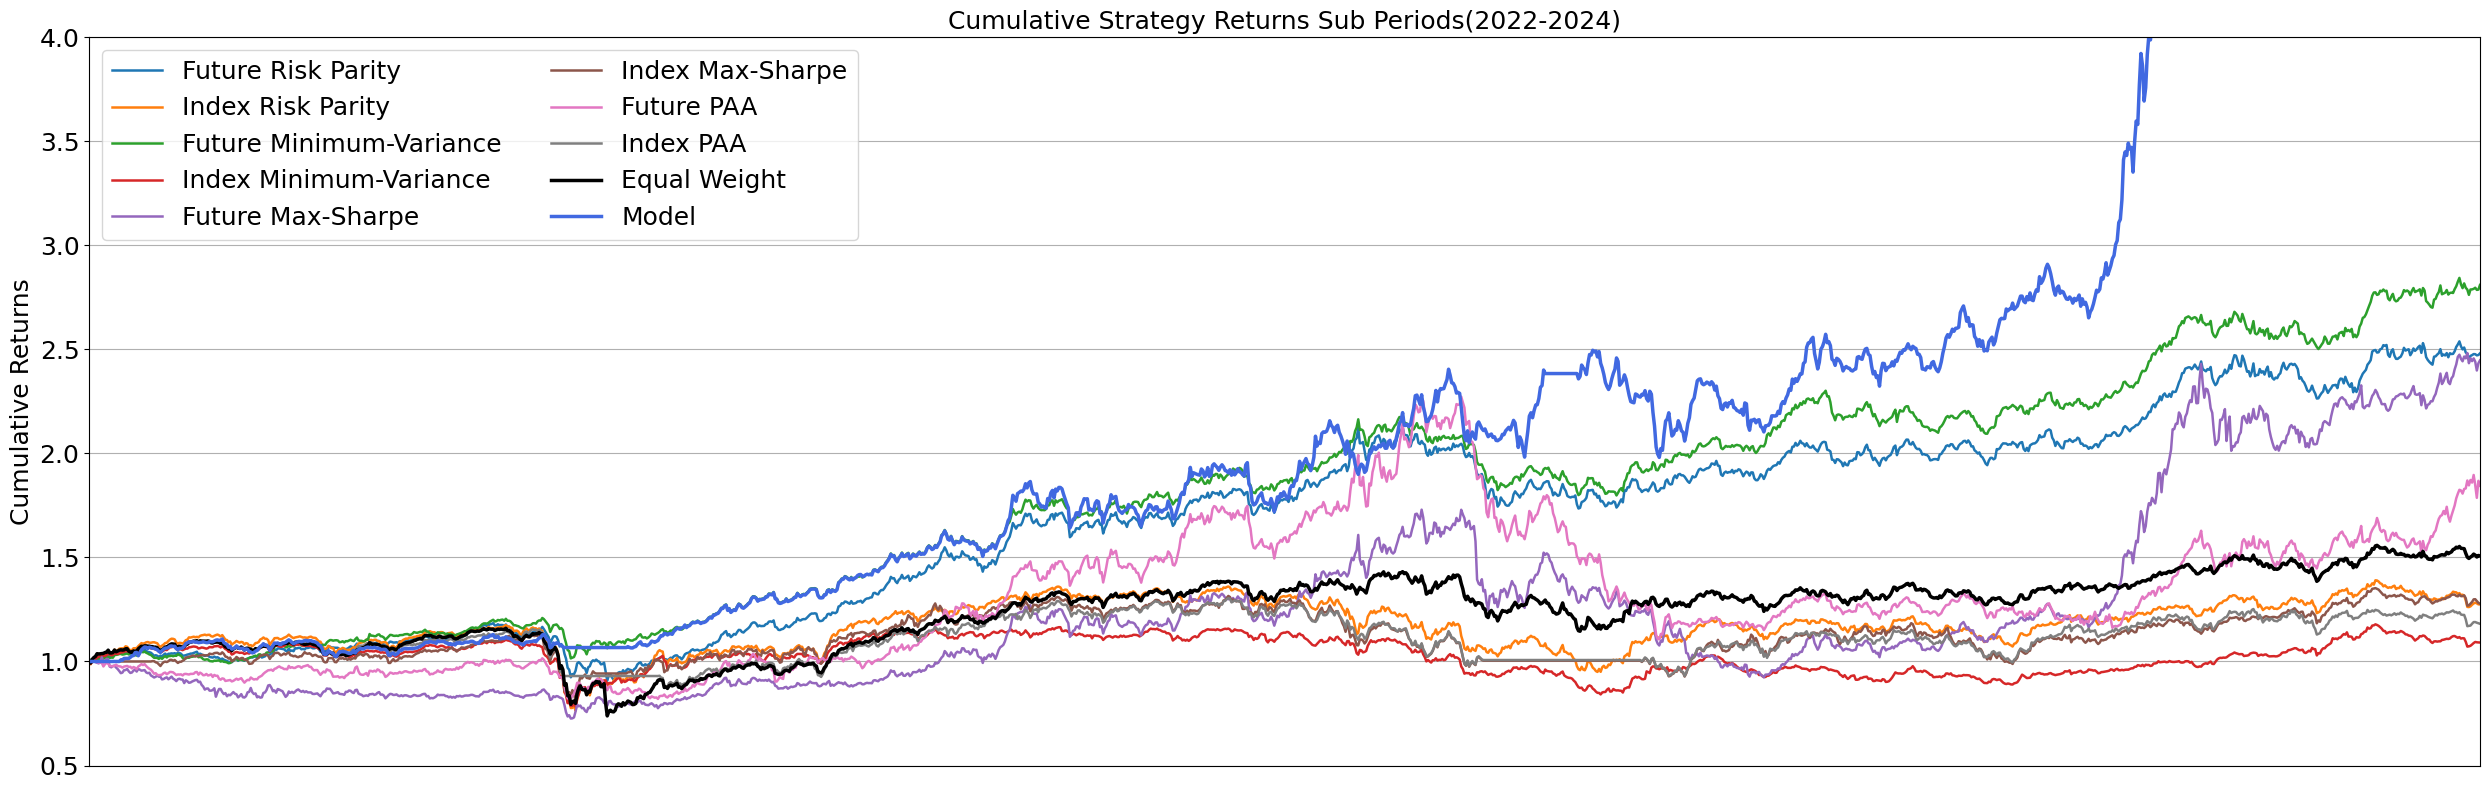

In [28]:
plot_cumulative_returns(renamed_returns_dict, "Cumulative Strategy Returns Sub Periods(2022-2024)", (0.5, 4))

In [29]:
# RP = pd.DataFrame(strategy_returns["RP"], columns=["RP"])
# Model = pd.DataFrame(strategy_returns["Model"], columns=["Model"])
# GTAA = pd.DataFrame(strategy_returns["GTAA"], columns=["GTAA"])


In [30]:
# rp_test = RP.loc["2022-08-24":"2023-11-02"]
# Model_test = Model.loc["2022-08-24":"2023-11-02"]
# gtaa_test = GTAA.loc["2022-08-24":"2023-11-02"]

In [31]:
metrics_summary = get_performance_summary(
    renamed_returns_dict,
    annual_factor=252,
    risk_free_rate=0.0
)

display(metrics_summary)


,Cumulative Return,Annual Return,Volatility,Sharpe Ratio,MDD
Future Risk Parity,1.481170,0.163759,0.135278,1.210539,0.233582
Index Risk Parity,0.274334,0.041287,0.159195,0.259349,0.350022
Future Minimum-Variance,1.809858,0.188173,0.118635,1.586152,0.176238
Index Minimum-Variance,0.091041,0.014648,0.121338,0.120717,0.292026
Future Max-Sharpe,1.447418,0.161102,0.232399,0.693214,0.465971
Index Max-Sharpe,0.277859,0.041767,0.164069,0.254571,0.294683
Future PAA,0.844737,0.107595,0.219106,0.491065,0.513095
Index PAA,0.181184,0.028179,0.145184,0.194093,0.286628
Equal Weight,0.507161,0.070860,0.151195,0.468664,0.363214
Model,4.573066,0.332029,0.198561,1.672177,0.206332


In [14]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd

# dominant_one_hot = pd.get_dummies(weight_rebal.idxmax(axis=1))

# all_strategies = weight_rebal.columns
# dominant_one_hot = dominant_one_hot.reindex(columns=all_strategies, fill_value=0).astype(float)


# # Heatmap 그리기
# fig, ax = plt.subplots(figsize=(25, 8))

# sns.heatmap(
#     dominant_one_hot.T,
#     cmap="Blues",
#     cbar=False,
#     linewidths=0.5,
#     linecolor='lightgray',
#     ax=ax
# )

# # 제목과 축 레이블 설정
# ax.set_title('Strategy Selection All Test Periods', fontsize=18)
# ax.set_xlabel('Date', fontsize=15)
# ax.set_ylabel('Strategy', fontsize=15)

# # x축 날짜 포맷팅
# step = max(1, len(weight_rebal.index) // 20)
# selected_ticks = weight_rebal.index[::step]

# ax.set_xticks(range(0, len(weight_rebal.index), step))
# ax.set_xticklabels(selected_ticks, rotation=45, ha='right',  fontsize=12)
# ax.set_yticklabels(all_strategies, rotation=0, fontsize=12)

# # y축 전략 이름 정렬
# ax.set_yticklabels(all_strategies, rotation=0)

# plt.tight_layout()
# plt.show()


In [15]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd

# # One-hot encoding of the dominant strategy at each time point
# dominant_one_hot = pd.get_dummies(weight_rebal.idxmax(axis=1))

# # Ensure all strategies are included in the columns
# all_strategies = weight_rebal.columns
# dominant_one_hot = dominant_one_hot.reindex(columns=all_strategies, fill_value=0).astype(float)

# # Plot heatmap
# fig, ax = plt.subplots(figsize=(25, 8))

# sns.heatmap(
#     dominant_one_hot.T,
#     cmap="Blues",
#     cbar=False,
#     linewidths=0.5,
#     linecolor='lightgray',
#     ax=ax
# )

# # Set title and axis labels
# ax.set_title('Strategy Selection All Test Periods', fontsize=18)
# ax.set_xlabel('Date', fontsize=15)
# ax.set_ylabel('Strategy', fontsize=15)

# # Format x-axis ticks to show YYYY-MM only
# step = max(1, len(weight_rebal.index) // 20)
# selected_ticks = weight_rebal.index[::step]
# formatted_ticks = pd.to_datetime(selected_ticks).strftime('%Y-%m')

# ax.set_xticks(range(0, len(weight_rebal.index), step))
# ax.set_xticklabels(formatted_ticks, rotation=45, ha='right', fontsize=12)

# # Set y-axis tick labels
# ax.set_yticklabels(all_strategies, rotation=0, fontsize=12)

# plt.tight_layout()
# plt.show()


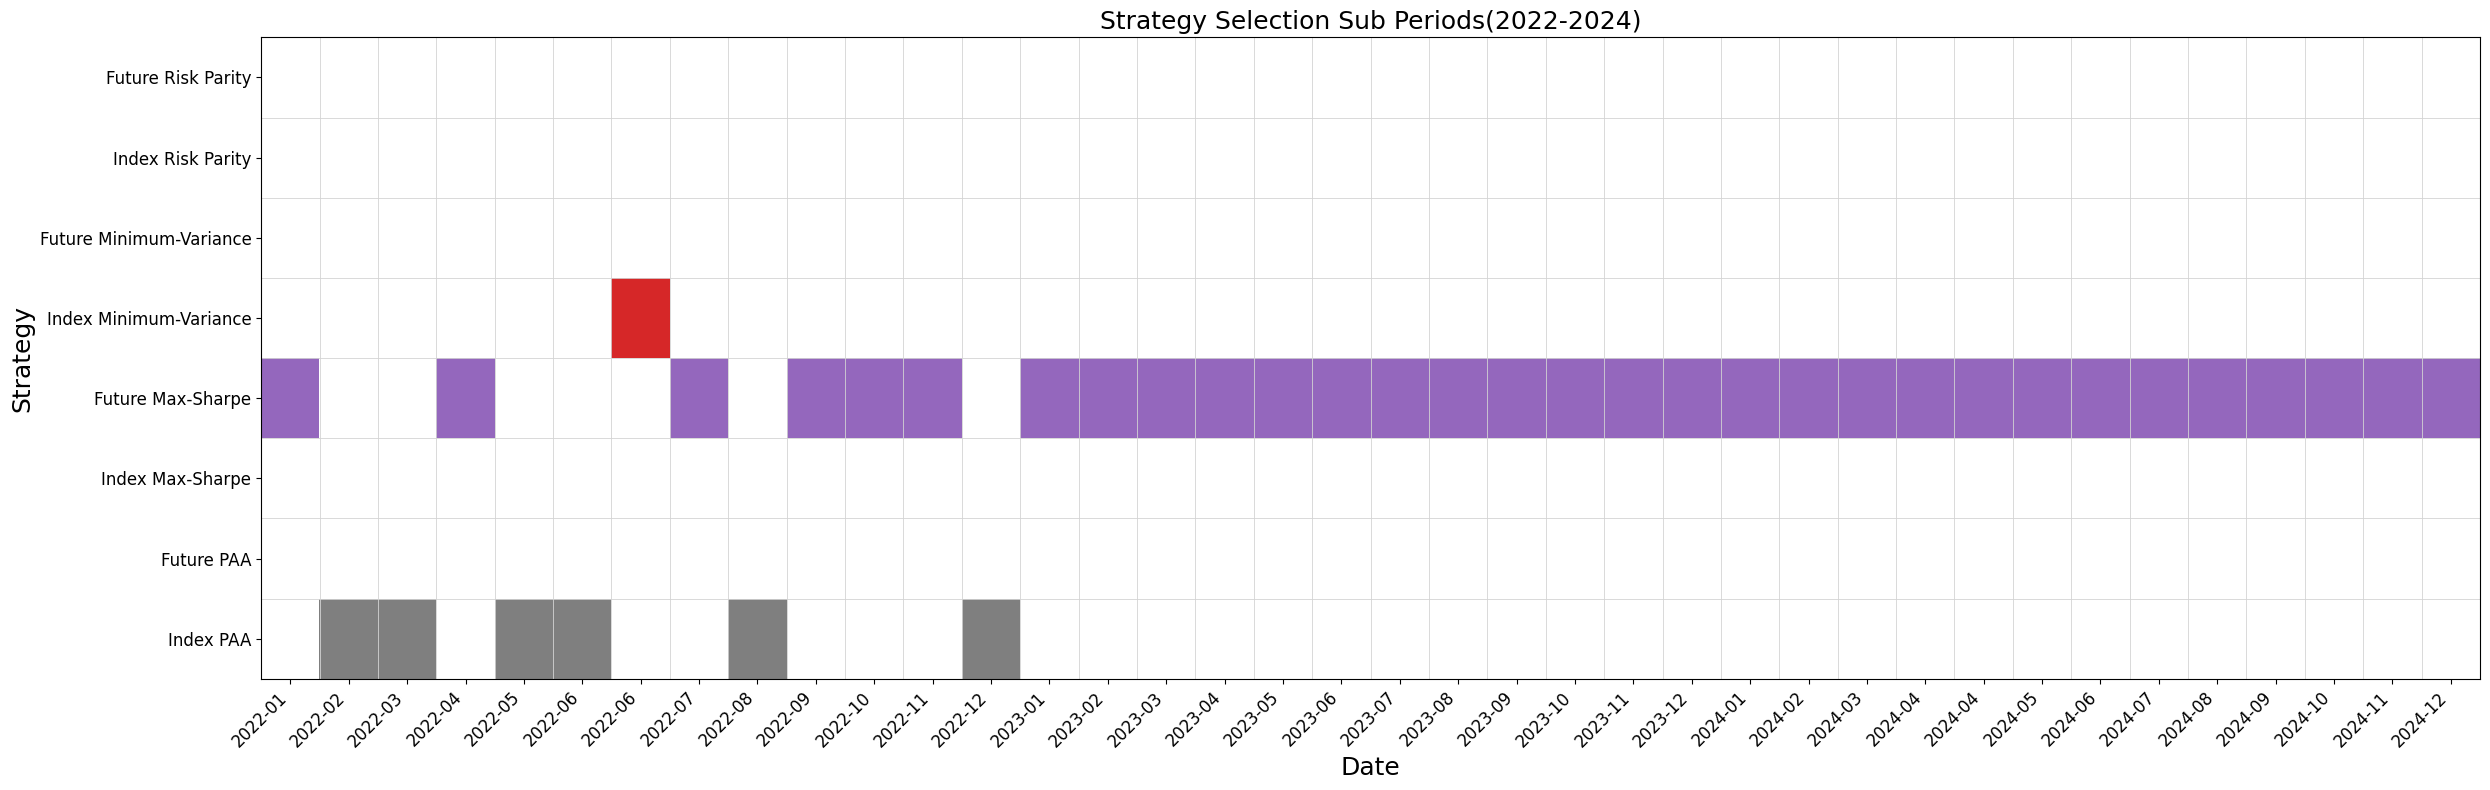

In [16]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 사용자 지정 전략 색상 (보다 진하고 명확한 색상)
color_map = {
        'Model': '#4169E1',                  # Royal Blue
        'Future Risk parity': '#1f77b4',     # Blue
        'Index Risk parity': '#ff7f0e',      # Orange
        'Future Minimum-Variance': '#2ca02c',# Green
        'Index Minimum-Variance': '#d62728', # Red
        'Future Max-Sharpe': '#9467bd',      # Purple
        'Index Max-Sharpe': '#8c564b',       # Brown
        'Future PAA': '#e377c2',             # Pink
        'Index PAA': '#7f7f7f',              # Gray
        'Equal Weight': 'black'            # Olive
    }

# weight_rebal.columns에서 각 전략 이름에 맞춰 색상 매핑
strategy_colors = {}
for strategy in weight_rebal.columns:
    for key in color_map:
        if key in strategy:  # 부분 일치 허용 (예: index_rp, future_paa 등)
            strategy_colors[strategy] = color_map[key]
            break
    else:
        strategy_colors[strategy] = 'lightgray'  # 매칭 안 될 경우 기본색

# 색상 배열 생성 (RGBA)
color_array = np.ones(weight_rebal.T.shape + (4,), dtype=float)  # 기본 흰색
for i, strategy in enumerate(weight_rebal.columns):
    rgba = plt.matplotlib.colors.to_rgba(strategy_colors[strategy])
    for j in range(weight_rebal.shape[0]):
        if weight_rebal.iloc[j, weight_rebal.columns.get_loc(strategy)] == 1:
            color_array[i, j] = rgba

# Plot
fig, ax = plt.subplots(figsize=(25, 8))
ax.imshow(color_array, aspect='auto')

# 축 설정
ax.set_yticks(np.arange(len(weight_rebal.columns)))
ax.set_yticklabels(weight_rebal.columns, fontsize=12)

step = max(1, len(weight_rebal.index) // 20)
xticks = np.arange(0, len(weight_rebal.index), step)
ax.set_xticks(xticks)
ax.set_xticklabels(pd.to_datetime(weight_rebal.index[::step]).strftime('%Y-%m'), rotation=45, ha='right', fontsize=12)

ax.set_xlabel('Date', fontsize=18)
ax.set_ylabel('Strategy', fontsize=18)
ax.set_title('Strategy Selection Sub Periods(2022-2024)', fontsize=18)

# ✅ Grid 라인 추가
for y in np.arange(len(weight_rebal.columns) + 1) - 0.5:
    ax.axhline(y=y, color='lightgray', linewidth=0.6)
for x in np.arange(len(weight_rebal.index) + 1) - 0.5:
    ax.axvline(x=x, color='lightgray', linewidth=0.6)

plt.tight_layout()
plt.show()
